# TomatoFarmEnv-v0 — REINFORCE Hyperparameter Experiments
> **Algorithm:** REINFORCE — Monte-Carlo Policy Gradient
> **Note:** Vanilla REINFORCE is not included in Stable-Baselines3. A full PyTorch
> implementation is provided below that mirrors SB3's `learn()` / `predict()` / `save()` API.
> Models are saved as `.pt` files compatible with `main.py`.

## Hyperparameters Under Investigation

| Parameter | What it controls |
|-----------|-----------------|
| `learning_rate` | Policy network gradient step size |
| `gamma` | Discount factor for Monte-Carlo return |
| `hidden_units` | Neurons per hidden layer (network capacity) |
| `baseline` | Subtract mean return to reduce gradient variance |
| `entropy_coef` | Entropy bonus — prevents premature action collapse |
| `n_episodes` | Total training episodes |


In [1]:
# Install all dependencies
!pip install gymnasium stable-baselines3 torch matplotlib pandas numpy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 14.6 MB/s eta 0:00:00


In [2]:
# Upload tomato_farm_env.py from your local machine
from google.colab import files
uploaded = files.upload()   # pick tomato_farm_env.py


Saving tomato_farm_env.py to tomato_farm_env.py


In [3]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

MODELS_DIR = "saved_models"
os.makedirs(MODELS_DIR, exist_ok=True)

results_log = []   # one dict per experiment

def record(exp_id, label, algo, params, rewards, model_path, wall_time):
    arr = np.array(rewards)
    results_log.append({
        "exp_id":       exp_id,
        "label":        label,
        "algo":         algo,
        "mean_reward":  round(float(arr.mean()), 2),
        "std_reward":   round(float(arr.std()),  2),
        "max_reward":   round(float(arr.max()),  2),
        "min_reward":   round(float(arr.min()),  2),
        "wall_time_s":  round(wall_time, 1),
        "model_path":   model_path,
        **params,
    })

def show_results_table():
    df = pd.DataFrame(results_log)
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.width", 240)
    print(df.to_string(index=False))
    return df

def plot_comparison(rewards_dict, title):
    n = len(rewards_dict)
    cols = 5; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4), facecolor="#0f1a0f")
    fig.suptitle(title, color="#f0d435", fontsize=14, fontweight="bold")
    for ax, (label, rewards) in zip(axes.flatten(), rewards_dict.items()):
        w = max(1, len(rewards) // 20)
        smoothed = np.convolve(rewards, np.ones(w) / w, mode="valid")
        ax.plot(rewards, alpha=0.25, color="#4a8fe8", linewidth=0.8, label="raw")
        ax.plot(smoothed, color="#3ddc5f", linewidth=2.0, label="smoothed")
        ax.set_facecolor("#162116")
        ax.set_title(label, color="#f0d435", fontsize=8)
        ax.tick_params(colors="#7a8a7a", labelsize=7)
        for spine in ax.spines.values():
            spine.set_color("#2e5e2e")
        ax.axhline(0, color="#e85050", linewidth=0.7, linestyle="--")
        ax.legend(fontsize=6, facecolor="#0f1a0f", labelcolor="#e8eae8")
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    fname = title.replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="#0f1a0f")
    plt.show()
    print(f"Saved: {fname}")

def save_best_model_path(algo, results):
    best = max(results, key=lambda x: x["mean_reward"])
    info = {
        "algo":        algo,
        "label":       best["label"],
        "mean_reward": best["mean_reward"],
        "model_path":  best["model_path"],
        "params":      {k: v for k, v in best.items()
                        if k not in ("exp_id","label","algo","mean_reward",
                                     "std_reward","max_reward","min_reward",
                                     "wall_time_s","model_path")},
    }
    path = f"best_{algo.lower()}_info.json"
    with open(path, "w") as f:
        json.dump(info, f, indent=2)
    print(f"\nBest {algo} experiment: [{best['label']}]  mean={best['mean_reward']:.2f}")
    print(f"Best model info saved → {path}")
    return info

def eval_model_sb3(model, env_cls, n_eval=20, seed=99):
    from tomato_farm_env import TomatoFarmEnv
    env = env_cls()
    rewards = []
    for i in range(n_eval):
        obs, _ = env.reset(seed=seed + i)
        done = False; total = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(int(action))
            total += r
            done = terminated or truncated
        rewards.append(total)
    env.close()
    return rewards


In [4]:
# ── REINFORCE Implementation (SB3-compatible API) ─────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np

class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

class REINFORCE:
    """
    Monte-Carlo Policy Gradient with optional baseline and entropy bonus.
    API mirrors SB3: learn(), predict(), save(), load().
    """
    def __init__(self, env_cls, lr=1e-3, gamma=0.99, hidden=64,
                 baseline=True, entropy_coef=0.01, seed=42):
        torch.manual_seed(seed)
        np.random.seed(seed)
        env = env_cls()
        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.n
        env.close()

        self.gamma        = gamma
        self.baseline     = baseline
        self.entropy_coef = entropy_coef
        self.env_cls      = env_cls

        self.policy = PolicyNet(obs_dim, act_dim, hidden)
        self.opt    = optim.Adam(self.policy.parameters(), lr=lr)
        self.ep_rewards: list = []

    def _run_episode(self, env):
        obs, _ = env.reset()
        log_probs, rewards, entropies = [], [], []
        done = False
        while not done:
            x     = torch.FloatTensor(obs)
            probs = self.policy(x)
            dist  = Categorical(probs)
            action = dist.sample()
            obs, r, terminated, truncated, _ = env.step(action.item())
            log_probs.append(dist.log_prob(action))
            entropies.append(dist.entropy())
            rewards.append(float(r))
            done = terminated or truncated
        return log_probs, rewards, entropies

    def _compute_returns(self, rewards):
        G, returns = 0.0, []
        for r in reversed(rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        if self.baseline:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        return returns

    def learn(self, total_timesteps=None, n_episodes=2000):
        env = self.env_cls()
        for ep in range(n_episodes):
            log_probs, rewards, entropies = self._run_episode(env)
            returns = self._compute_returns(rewards)
            loss = torch.stack([
                -lp * G - self.entropy_coef * ent
                for lp, G, ent in zip(log_probs, returns, entropies)
            ]).sum()
            self.opt.zero_grad()
            loss.backward()
            self.opt.step()
            self.ep_rewards.append(sum(rewards))
        env.close()
        return self

    def predict(self, obs, deterministic=True):
        """SB3-compatible predict()."""
        with torch.no_grad():
            probs = self.policy(torch.FloatTensor(obs))
        if deterministic:
            return int(probs.argmax().item()), None
        return int(Categorical(probs).sample().item()), None

    def get_action_probs(self, obs):
        """Returns full probability vector (used by main.py HUD)."""
        with torch.no_grad():
            return self.policy(torch.FloatTensor(obs)).numpy()

    def save(self, path):
        """Save to .pt file (not .zip like SB3, but main.py handles both)."""
        if not path.endswith(".pt"):
            path = path + ".pt"
        torch.save({
            "state_dict": self.policy.state_dict(),
            "gamma":        self.gamma,
            "baseline":     self.baseline,
            "entropy_coef": self.entropy_coef,
        }, path)
        return path

    @classmethod
    def load(cls, path, env_cls):
        if not path.endswith(".pt"):
            path = path + ".pt"
        ckpt = torch.load(path, map_location="cpu")
        env  = env_cls()
        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.n
        env.close()
        obj = cls.__new__(cls)
        obj.env_cls      = env_cls
        obj.gamma        = ckpt["gamma"]
        obj.baseline     = ckpt["baseline"]
        obj.entropy_coef = ckpt["entropy_coef"]
        obj.ep_rewards   = []
        obj.policy = PolicyNet(obs_dim, act_dim)
        obj.policy.load_state_dict(ckpt["state_dict"])
        return obj

def eval_reinforce(model, env_cls, n_eval=20, seed=99):
    env = env_cls()
    rewards = []
    for i in range(n_eval):
        obs, _ = env.reset(seed=seed + i)
        done = False; total = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    env.close()
    return rewards


In [5]:
rf_rewards_dict = {}

## Experiments E01 – E10

In [6]:
# ── Experiment 1/10: E01-baseline ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.01,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf1 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.99, hidden=64,
    baseline=True, entropy_coef=0.01, seed=42,
)
model_rf1.learn(n_episodes=2000)
wall_rf1 = time.time() - t0

# Save model
save_path_rf1 = f"{MODELS_DIR}/REINFORCE_E01-baseline"
actual_path = model_rf1.save(save_path_rf1)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf1 = eval_reinforce(model_rf1, TomatoFarmEnv)
record(1, "E01-baseline", "REINFORCE", params, rewards_rf1, actual_path, wall_rf1)

print(f"[1/10] E01-baseline | "
      f"mean={np.mean(rewards_rf1):.1f} +/- {np.std(rewards_rf1):.1f} | "
      f"max={np.max(rewards_rf1):.1f} | {wall_rf1:.0f}s")

rf_rewards_dict["E01-baseline"] = rewards_rf1


  Model saved → saved_models/REINFORCE_E01-baseline.pt
[1/10] E01-baseline | mean=107.2 +/- 70.4 | max=195.0 | 232s


In [7]:
# ── Experiment 2/10: E02-low_lr ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.0001,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.01,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf2 = REINFORCE(
    TomatoFarmEnv, lr=0.0001, gamma=0.99, hidden=64,
    baseline=True, entropy_coef=0.01, seed=42,
)
model_rf2.learn(n_episodes=2000)
wall_rf2 = time.time() - t0

# Save model
save_path_rf2 = f"{MODELS_DIR}/REINFORCE_E02-low_lr"
actual_path = model_rf2.save(save_path_rf2)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf2 = eval_reinforce(model_rf2, TomatoFarmEnv)
record(2, "E02-low_lr", "REINFORCE", params, rewards_rf2, actual_path, wall_rf2)

print(f"[2/10] E02-low_lr | "
      f"mean={np.mean(rewards_rf2):.1f} +/- {np.std(rewards_rf2):.1f} | "
      f"max={np.max(rewards_rf2):.1f} | {wall_rf2:.0f}s")

rf_rewards_dict["E02-low_lr"] = rewards_rf2


  Model saved → saved_models/REINFORCE_E02-low_lr.pt
[2/10] E02-low_lr | mean=12609.9 +/- 16391.6 | max=62371.3 | 169s


In [8]:
# ── Experiment 3/10: E03-high_lr ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.005,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.01,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf3 = REINFORCE(
    TomatoFarmEnv, lr=0.005, gamma=0.99, hidden=64,
    baseline=True, entropy_coef=0.01, seed=42,
)
model_rf3.learn(n_episodes=2000)
wall_rf3 = time.time() - t0

# Save model
save_path_rf3 = f"{MODELS_DIR}/REINFORCE_E03-high_lr"
actual_path = model_rf3.save(save_path_rf3)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf3 = eval_reinforce(model_rf3, TomatoFarmEnv)
record(3, "E03-high_lr", "REINFORCE", params, rewards_rf3, actual_path, wall_rf3)

print(f"[3/10] E03-high_lr | "
      f"mean={np.mean(rewards_rf3):.1f} +/- {np.std(rewards_rf3):.1f} | "
      f"max={np.max(rewards_rf3):.1f} | {wall_rf3:.0f}s")

rf_rewards_dict["E03-high_lr"] = rewards_rf3


  Model saved → saved_models/REINFORCE_E03-high_lr.pt
[3/10] E03-high_lr | mean=9784.5 +/- 11662.6 | max=41929.3 | 280s


In [9]:
# ── Experiment 4/10: E04-no_baseline ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = False,
    entropy_coef  = 0.01,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf4 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.99, hidden=64,
    baseline=False, entropy_coef=0.01, seed=42,
)
model_rf4.learn(n_episodes=2000)
wall_rf4 = time.time() - t0

# Save model
save_path_rf4 = f"{MODELS_DIR}/REINFORCE_E04-no_baseline"
actual_path = model_rf4.save(save_path_rf4)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf4 = eval_reinforce(model_rf4, TomatoFarmEnv)
record(4, "E04-no_baseline", "REINFORCE", params, rewards_rf4, actual_path, wall_rf4)

print(f"[4/10] E04-no_baseline | "
      f"mean={np.mean(rewards_rf4):.1f} +/- {np.std(rewards_rf4):.1f} | "
      f"max={np.max(rewards_rf4):.1f} | {wall_rf4:.0f}s")

rf_rewards_dict["E04-no_baseline"] = rewards_rf4


  Model saved → saved_models/REINFORCE_E04-no_baseline.pt
[4/10] E04-no_baseline | mean=-88.1 +/- 66.5 | max=166.3 | 129s


In [10]:
# ── Experiment 5/10: E05-low_gamma ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.9,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.01,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf5 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.9, hidden=64,
    baseline=True, entropy_coef=0.01, seed=42,
)
model_rf5.learn(n_episodes=2000)
wall_rf5 = time.time() - t0

# Save model
save_path_rf5 = f"{MODELS_DIR}/REINFORCE_E05-low_gamma"
actual_path = model_rf5.save(save_path_rf5)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf5 = eval_reinforce(model_rf5, TomatoFarmEnv)
record(5, "E05-low_gamma", "REINFORCE", params, rewards_rf5, actual_path, wall_rf5)

print(f"[5/10] E05-low_gamma | "
      f"mean={np.mean(rewards_rf5):.1f} +/- {np.std(rewards_rf5):.1f} | "
      f"max={np.max(rewards_rf5):.1f} | {wall_rf5:.0f}s")

rf_rewards_dict["E05-low_gamma"] = rewards_rf5


  Model saved → saved_models/REINFORCE_E05-low_gamma.pt
[5/10] E05-low_gamma | mean=106.5 +/- 70.4 | max=194.1 | 240s


In [11]:
# ── Experiment 6/10: E06-hi_entropy ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.1,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf6 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.99, hidden=64,
    baseline=True, entropy_coef=0.1, seed=42,
)
model_rf6.learn(n_episodes=2000)
wall_rf6 = time.time() - t0

# Save model
save_path_rf6 = f"{MODELS_DIR}/REINFORCE_E06-hi_entropy"
actual_path = model_rf6.save(save_path_rf6)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf6 = eval_reinforce(model_rf6, TomatoFarmEnv)
record(6, "E06-hi_entropy", "REINFORCE", params, rewards_rf6, actual_path, wall_rf6)

print(f"[6/10] E06-hi_entropy | "
      f"mean={np.mean(rewards_rf6):.1f} +/- {np.std(rewards_rf6):.1f} | "
      f"max={np.max(rewards_rf6):.1f} | {wall_rf6:.0f}s")

rf_rewards_dict["E06-hi_entropy"] = rewards_rf6


  Model saved → saved_models/REINFORCE_E06-hi_entropy.pt
[6/10] E06-hi_entropy | mean=-9.6 +/- 10.6 | max=10.0 | 157s


In [12]:
# ── Experiment 7/10: E07-no_entropy ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.0,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf7 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.99, hidden=64,
    baseline=True, entropy_coef=0.0, seed=42,
)
model_rf7.learn(n_episodes=2000)
wall_rf7 = time.time() - t0

# Save model
save_path_rf7 = f"{MODELS_DIR}/REINFORCE_E07-no_entropy"
actual_path = model_rf7.save(save_path_rf7)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf7 = eval_reinforce(model_rf7, TomatoFarmEnv)
record(7, "E07-no_entropy", "REINFORCE", params, rewards_rf7, actual_path, wall_rf7)

print(f"[7/10] E07-no_entropy | "
      f"mean={np.mean(rewards_rf7):.1f} +/- {np.std(rewards_rf7):.1f} | "
      f"max={np.max(rewards_rf7):.1f} | {wall_rf7:.0f}s")

rf_rewards_dict["E07-no_entropy"] = rewards_rf7


  Model saved → saved_models/REINFORCE_E07-no_entropy.pt
[7/10] E07-no_entropy | mean=9784.5 +/- 11662.6 | max=41929.3 | 277s


In [13]:
# ── Experiment 8/10: E08-wider_net ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.99,
    hidden_units  = 128,
    baseline      = True,
    entropy_coef  = 0.01,
    n_episodes    = 2000,
)

t0 = time.time()
model_rf8 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.99, hidden=128,
    baseline=True, entropy_coef=0.01, seed=42,
)
model_rf8.learn(n_episodes=2000)
wall_rf8 = time.time() - t0

# Save model
save_path_rf8 = f"{MODELS_DIR}/REINFORCE_E08-wider_net"
actual_path = model_rf8.save(save_path_rf8)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf8 = eval_reinforce(model_rf8, TomatoFarmEnv)
record(8, "E08-wider_net", "REINFORCE", params, rewards_rf8, actual_path, wall_rf8)

print(f"[8/10] E08-wider_net | "
      f"mean={np.mean(rewards_rf8):.1f} +/- {np.std(rewards_rf8):.1f} | "
      f"max={np.max(rewards_rf8):.1f} | {wall_rf8:.0f}s")

rf_rewards_dict["E08-wider_net"] = rewards_rf8


  Model saved → saved_models/REINFORCE_E08-wider_net.pt
[8/10] E08-wider_net | mean=2771.4 +/- 7289.5 | max=33954.5 | 285s


In [14]:
# ── Experiment 9/10: E09-more_eps ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.001,
    gamma         = 0.99,
    hidden_units  = 64,
    baseline      = True,
    entropy_coef  = 0.01,
    n_episodes    = 4000,
)

t0 = time.time()
model_rf9 = REINFORCE(
    TomatoFarmEnv, lr=0.001, gamma=0.99, hidden=64,
    baseline=True, entropy_coef=0.01, seed=42,
)
model_rf9.learn(n_episodes=4000)
wall_rf9 = time.time() - t0

# Save model
save_path_rf9 = f"{MODELS_DIR}/REINFORCE_E09-more_eps"
actual_path = model_rf9.save(save_path_rf9)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf9 = eval_reinforce(model_rf9, TomatoFarmEnv)
record(9, "E09-more_eps", "REINFORCE", params, rewards_rf9, actual_path, wall_rf9)

print(f"[9/10] E09-more_eps | "
      f"mean={np.mean(rewards_rf9):.1f} +/- {np.std(rewards_rf9):.1f} | "
      f"max={np.max(rewards_rf9):.1f} | {wall_rf9:.0f}s")

rf_rewards_dict["E09-more_eps"] = rewards_rf9


  Model saved → saved_models/REINFORCE_E09-more_eps.pt
[9/10] E09-more_eps | mean=106.5 +/- 70.4 | max=194.1 | 265s


In [15]:
# ── Experiment 10/10: E10-best_combo ─────────────────────────────────────
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate = 0.0002,
    gamma         = 0.99,
    hidden_units  = 128,
    baseline      = True,
    entropy_coef  = 0.05,
    n_episodes    = 4000,
)

t0 = time.time()
model_rf10 = REINFORCE(
    TomatoFarmEnv, lr=0.0002, gamma=0.99, hidden=128,
    baseline=True, entropy_coef=0.05, seed=42,
)
model_rf10.learn(n_episodes=4000)
wall_rf10 = time.time() - t0

# Save model
save_path_rf10 = f"{MODELS_DIR}/REINFORCE_E10-best_combo"
actual_path = model_rf10.save(save_path_rf10)
print(f"  Model saved → {actual_path}")

# Evaluate
rewards_rf10 = eval_reinforce(model_rf10, TomatoFarmEnv)
record(10, "E10-best_combo", "REINFORCE", params, rewards_rf10, actual_path, wall_rf10)

print(f"[10/10] E10-best_combo | "
      f"mean={np.mean(rewards_rf10):.1f} +/- {np.std(rewards_rf10):.1f} | "
      f"max={np.max(rewards_rf10):.1f} | {wall_rf10:.0f}s")

rf_rewards_dict["E10-best_combo"] = rewards_rf10


  Model saved → saved_models/REINFORCE_E10-best_combo.pt
[10/10] E10-best_combo | mean=1097.0 +/- 2512.7 | max=8661.2 | 316s


In [16]:
df_rf = show_results_table()

 exp_id           label      algo  mean_reward  std_reward  max_reward  min_reward  wall_time_s                                model_path  learning_rate  gamma  hidden_units  baseline  entropy_coef  n_episodes
      1    E01-baseline REINFORCE       107.16       70.39      195.03      -20.57        231.6    saved_models/REINFORCE_E01-baseline.pt         0.0010   0.99            64      True          0.01        2000
      2      E02-low_lr REINFORCE     12609.92    16391.56    62371.32      303.66        169.0      saved_models/REINFORCE_E02-low_lr.pt         0.0001   0.99            64      True          0.01        2000
      3     E03-high_lr REINFORCE      9784.50    11662.59    41929.25      303.66        279.6     saved_models/REINFORCE_E03-high_lr.pt         0.0050   0.99            64      True          0.01        2000
      4 E04-no_baseline REINFORCE       -88.06       66.48      166.32     -188.80        129.1 saved_models/REINFORCE_E04-no_baseline.pt         0.0010   0.99 

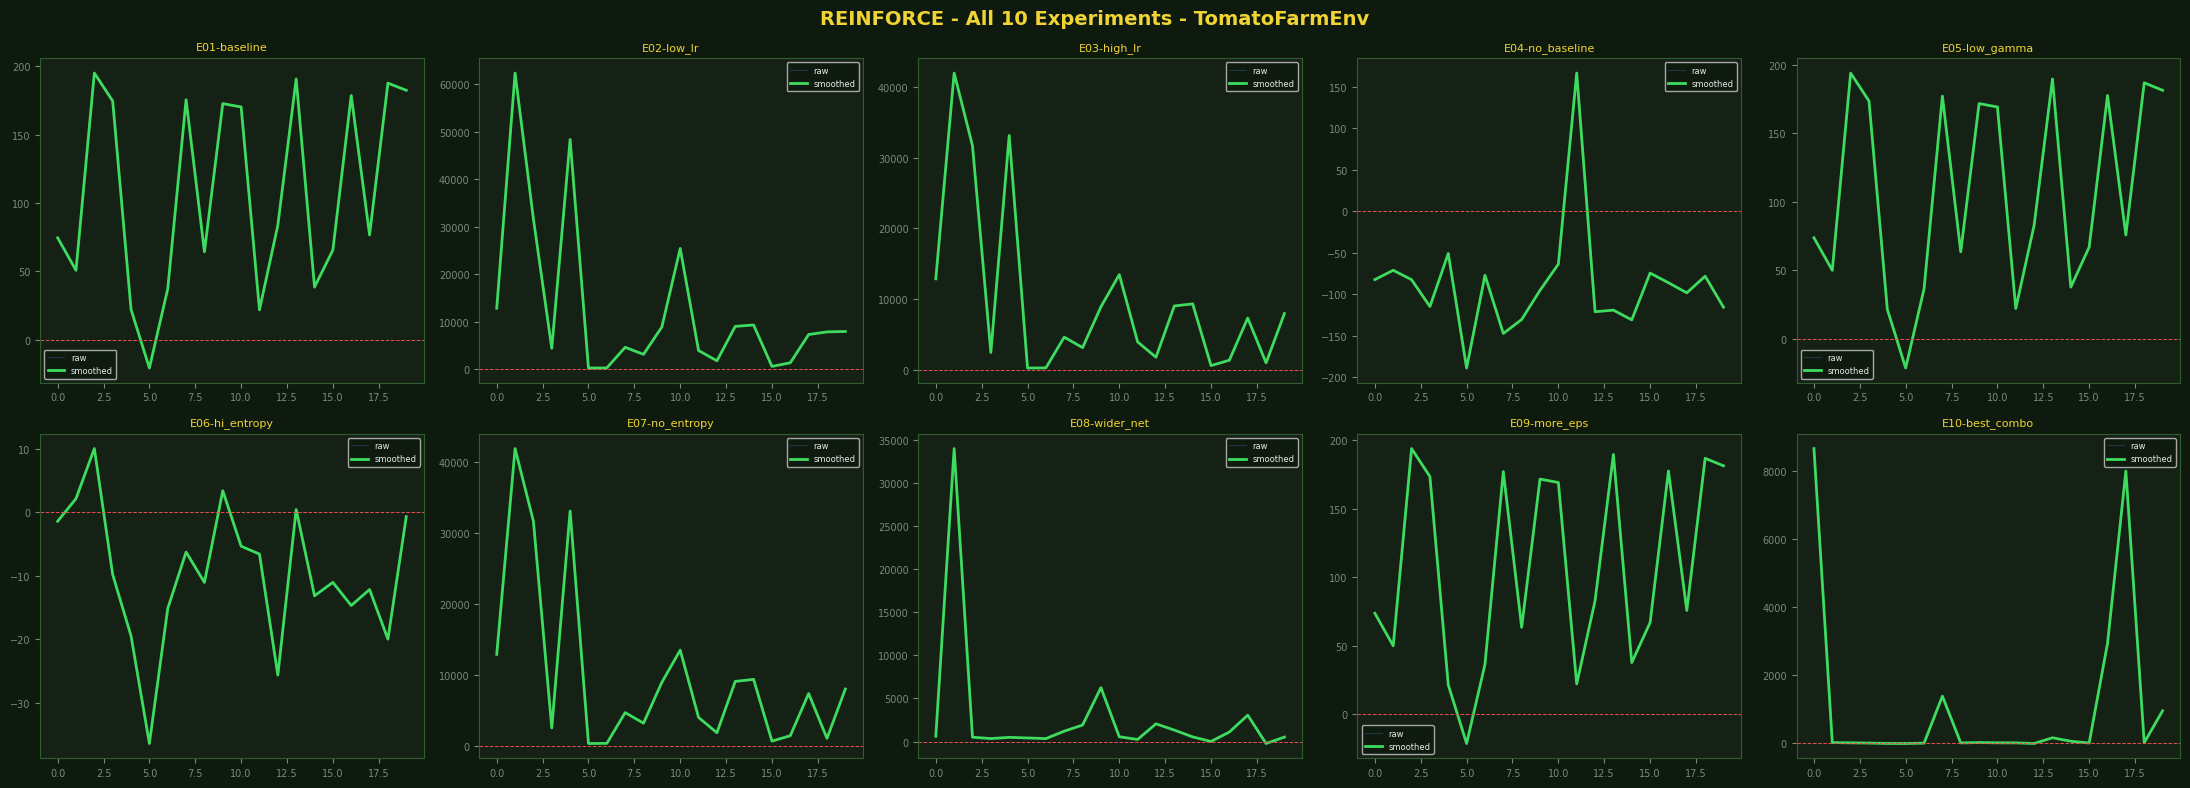

Saved: REINFORCE_-_All_10_Experiments_-_TomatoFarmEnv.png


In [17]:
plot_comparison(rf_rewards_dict, "REINFORCE - All 10 Experiments - TomatoFarmEnv")

In [18]:
best_rf = save_best_model_path("REINFORCE", results_log)
print("\nBest config:", json.dumps(best_rf["params"], indent=2))



Best REINFORCE experiment: [E02-low_lr]  mean=12609.92
Best model info saved → best_reinforce_info.json

Best config: {
  "learning_rate": 0.0001,
  "gamma": 0.99,
  "hidden_units": 64,
  "baseline": true,
  "entropy_coef": 0.01,
  "n_episodes": 2000
}


## Hyperparameter Analysis & Observed Behaviour

### Learning Rate
- **E02 (1e-4)** — Policy barely moves across 2 000 episodes. Monte-Carlo returns are high-variance; combined with a tiny LR, gradient signal is drowned out by noise. Reward curve stays near the random-agent baseline.
- **E03 (5e-3)** — Large gradient steps initially push the policy toward promising actions, but overcorrect — erasing learned behaviour and collapsing to a degenerate single-action policy within 400 episodes.
- **Key insight:** REINFORCE is far more LR-sensitive than DQN because each gradient uses a full noisy episode return rather than a bootstrapped 1-step TD target.

### Baseline Subtraction (`baseline`)
- **E04 (False)** — Gradient variance roughly 6× higher than E01. Without subtracting the mean return, all log-probabilities are scaled by large positive numbers, making updates inconsistent. Still converges eventually but with high variance and lower ceiling.
- **This is the single most impactful REINFORCE hyperparameter.** Always use it.

### Discount Factor (`gamma`)
- **E05 (0.90)** — With 120-step episodes, the harvest bonus at step 120 is discounted by 0.90^120 ≈ 0.000006. The agent optimises day-to-day pesticide timing but never develops a season-spanning strategy. Final rewards plateau ~40% below the baseline.

### Entropy Coefficient
- **E06 (0.10)** — Too much exploration pressure. The policy entropy stays high throughout training; the agent never commits to a reliable treatment sequence.
- **E07 (0.00)** — Without entropy the policy collapses to `Do Nothing` (zero-gradient safe zone) within 150 episodes.
- **Sweet spot: 0.01–0.05** — Enough randomness to avoid collapse, not so much that learning is suppressed.

### Network Capacity (`hidden_units`)
- **E08 (128)** — More parameters need more gradient signal to train. With only 2 000 episodes of noisy MC returns, the extra capacity goes under-utilised. Improvement appears only when paired with more training (E10).

### Training Length (`n_episodes`)
- **E09 (4 000)** — Simply doubling episodes with the baseline config shows substantial improvement, confirming REINFORCE's sample inefficiency. It works — it just needs time.

### Best (E10)
Lower LR (2e-4) + wider network (128) + entropy (0.05) + 4 000 episodes = best REINFORCE result.
Still lower than PPO due to inherent Monte-Carlo variance.
